<div style="text-align: center; padding: 30px 20px; border: 2px solid #2c3e50; border-radius: 10px;">

<h1 style="color: #2c3e50; margin-bottom: 5px;">Employee Attrition Feature Engineering</h1>

</div>

## 1. Understanding the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

%matplotlib inline
print('Libraries imported Successfully')

Libraries imported Successfully


In [2]:
df = pd.read_csv('Employee Attrition Dataset.csv')
df.head()

,Employee_ID,Age,Gender,Marital_Status,Education_Level,Department,Job_Role,Total_Work_Experience,Years_at_Company,Years_in_Current_Role,Promotion_Count,Business_Travel,Work_Mode,Distance_From_Home,Monthly_Salary,Annual_Bonus,Stock_Option_Value,Overtime_Hours,Monthly_Expenses,Compensation_Band,Performance_Rating,Manager_Rating,Training_Hours,Certification_Count,Project_Count,Job_Satisfaction,Work_Life_Balance,Environment_Satisfaction,Relationship_Satisfaction,Recognition_Score,Manager_Support,Engagement_Index,Productivity_Index,Financial_Stress_Index,Attendance_Score,Career_Growth_Index,Annual_Compensation,Experience_Band,Attrition
0,EMP100001,37,Male,Single,Bachelor,Engineering,Senior Engineer,15,7.8,5.0,2,Frequently,Hybrid,19.2,11032.61,17422.14,151484.41,4.7,5288.23,Medium,4,4.0,35.1,3,3,6,5,7.0,6,7,7,6.50,53.59,44.11,92.84,52.99,301297.87,Mid,0
1,EMP100002,27,Male,Single,Bachelor,Operations,Engineer,2,2.0,0.1,0,Never,Office,6.1,5953.93,14494.60,0.00,10.8,4232.64,Low,3,3.0,NaN,0,1,6,5,5.0,5,5,5,5.25,39.22,85.62,88.21,14.41,85941.76,Entry,0
2,EMP100003,41,Male,Married,Master,Finance,Manager,15,4.7,0.2,1,Frequently,Hybrid,4.9,22053.98,19612.16,232221.91,1.3,11040.13,High,3,4.0,31.8,0,8,6,4,6.0,4,9,4,5.75,49.53,36.18,90.69,36.18,516481.83,Mid,0
3,EMP100004,43,Male,Divorced,Bachelor,Finance,Manager,23,3.0,0.8,0,Never,Hybrid,15.0,27033.46,137192.60,111808.68,1.3,16966.09,High,4,5.0,31.6,0,8,6,6,5.0,6,6,8,6.50,59.97,50.70,89.36,31.91,573402.80,Senior,0
4,EMP100005,21,Male,Single,Bachelor,HR,Associate,0,0.0,0.0,0,Rarely,Hybrid,15.7,3253.53,4228.73,0.00,3.4,1435.83,Low,3,3.0,20.4,0,2,5,4,5.0,4,5,4,4.50,39.32,44.69,90.01,14.34,43271.09,Entry,0


### 1.1 Descriptive Statistics

In [3]:
# Attribute type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Employee_ID                5000 non-null   object 
 1   Age                        5000 non-null   int64  
 2   Gender                     5000 non-null   object 
 3   Marital_Status             5000 non-null   object 
 4   Education_Level            5000 non-null   object 
 5   Department                 5000 non-null   object 
 6   Job_Role                   5000 non-null   object 
 7   Total_Work_Experience      5000 non-null   int64  
 8   Years_at_Company           5000 non-null   float64
 9   Years_in_Current_Role      5000 non-null   float64
 10  Promotion_Count            5000 non-null   int64  
 11  Business_Travel            5000 non-null   object 
 12  Work_Mode                  5000 non-null   object 
 13  Distance_From_Home         5000 non-null   float

In [4]:
# Descriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,34.978800,7.708530,21.00,29.0000,35.000,40.0000,60.00
Total_Work_Experience,5000.0,12.669800,7.955767,0.00,7.0000,12.000,18.0000,41.00
Years_at_Company,5000.0,3.410080,2.679753,0.00,1.4000,2.900,4.9000,17.10
Years_in_Current_Role,5000.0,1.715520,1.845140,0.00,0.4000,1.100,2.4000,15.80
Promotion_Count,5000.0,0.609200,0.763015,0.00,0.0000,0.000,1.0000,4.00
Distance_From_Home,5000.0,15.356100,12.337019,0.10,6.8000,12.200,20.2000,103.50
Monthly_Salary,5000.0,11999.927000,7942.839669,2420.45,6279.6375,10458.250,15533.0925,93069.80
Annual_Bonus,4700.0,36710.677534,36451.119511,176.62,13545.2750,25993.180,47960.6675,408826.73
Stock_Option_Value,5000.0,130869.447020,231877.594476,0.00,0.0000,0.000,203840.5050,2912175.45
Overtime_Hours,5000.0,8.974564,6.739951,0.10,4.2000,7.200,12.0250,54.21


In [5]:
df.describe(include='object').T

,count,unique,top,freq
Employee_ID,5000,5000,EMP100001,1
Gender,5000,3,Male,2887
Marital_Status,5000,3,Married,2924
Education_Level,5000,4,Bachelor,2734
Department,5000,7,Engineering,1747
Job_Role,5000,6,Senior Engineer,1409
Business_Travel,5000,3,Never,2050
Work_Mode,5000,3,Hybrid,2225
Compensation_Band,5000,3,Low,1667
Experience_Band,5000,4,Mid,2120


### 1.2 Duplicate and Missing values

In [6]:
# Duplicate Values check
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Employee_ID values:", df['Employee_ID'].duplicated().sum())
print("Employee_ID is unique:", df['Employee_ID'].is_unique)

Duplicate rows: 0
Duplicate Employee_ID values: 0
Employee_ID is unique: True


Each row represents a distinct employee, as expected.

In [7]:
# Missing Values check
missing_count = df.isnull().sum()
missing_summary = pd.DataFrame({'Missing_Count': missing_count})
missing_summary = missing_summary[missing_summary.Missing_Count > 0].sort_values('Missing_Count', ascending=False)
missing_summary

,Missing_Count
Training_Hours,350
Annual_Bonus,300
Manager_Rating,250
Environment_Satisfaction,250


Four columns contain missing values. No column is missing more than 7% of its values, so dropping columns is not necessary.

### 1.3 Feature Classification

Each of the 39 columns is classified below into one of six groups. This classification drives which preprocessing techniques are appropriate for each
column later on.

In [8]:
feature_types = {
    'Identifier': ['Employee_ID'],
    'Numeric_Continuous': ['Age', 'Total_Work_Experience', 'Years_at_Company', 'Years_in_Current_Role', 'Distance_From_Home', 'Monthly_Salary', 
                           'Annual_Bonus', 'Stock_Option_Value', 'Overtime_Hours', 'Monthly_Expenses', 'Training_Hours', 'Engagement_Index', 
                           'Productivity_Index', 'Financial_Stress_Index', 'Attendance_Score', 'Career_Growth_Index', 'Annual_Compensation'],
    'Numeric_Discrete': ['Promotion_Count', 'Certification_Count', 'Project_Count'],
    'Numeric_Ordinal': ['Performance_Rating', 'Manager_Rating', 'Job_Satisfaction', 'Work_Life_Balance', 'Environment_Satisfaction', 
                          'Relationship_Satisfaction', 'Recognition_Score', 'Manager_Support'],
    'Categorical_Nominal': ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Business_Travel', 'Work_Mode'],
    'Categorical_Ordinal': ['Education_Level', 'Compensation_Band', 'Performance_Rating', 'Manager_Rating', 'Job_Satisfaction', 'Work_Life_Balance', 
                            'Environment_Satisfaction', 'Relationship_Satisfaction', 'Recognition_Score', 'Manager_Support', 'Experience_Band'],
    'Target': ['Attrition']}

### 1.4 Numerical Feature Distributions

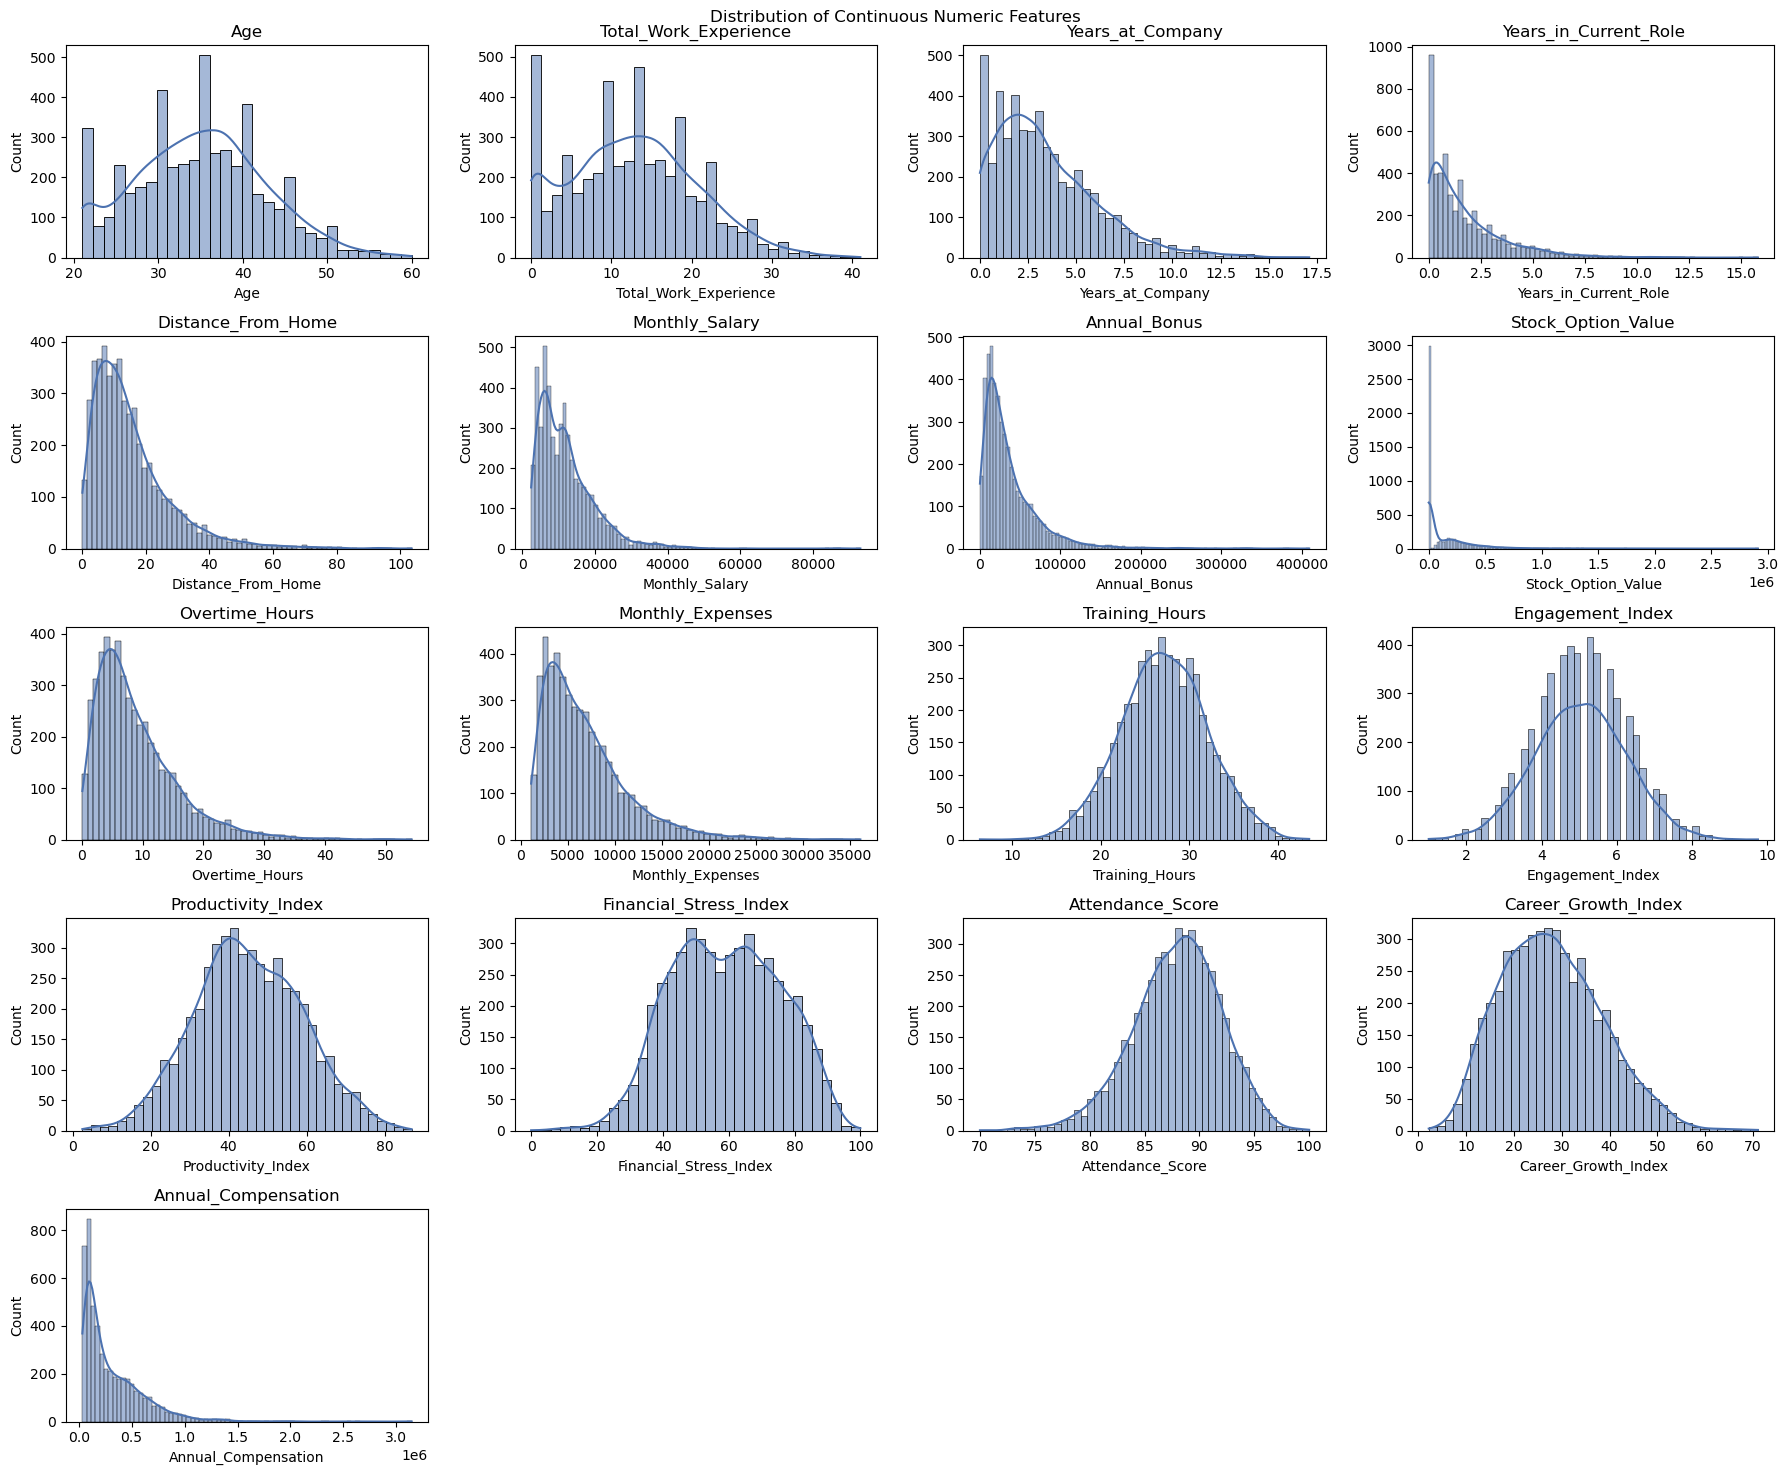

In [9]:
continuous_cols = feature_types['Numeric_Continuous']
fig, axes = plt.subplots(5, 4, figsize=(18, 15))
axes = axes.flatten()
for ax, col in zip(axes, continuous_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#4C72B0')
    ax.set_title(col)

for i in range(-3,0):
    axes[i].axis('off') 
plt.suptitle('Distribution of Continuous Numeric Features')
plt.tight_layout()
plt.show()

Several patterns stand out:
- Compensation-related features (`Monthly_Salary`, `Annual_Bonus`, `Stock_Option_Value`, `Annual_Compensation`) are strongly right-skewed, typical of pay/wealth data.
- `Stock_Option_Value` shows a large spike at zero — many employees simply receive no stock options, so the distribution is zero-inflated rather than purely continuous.
- Tenure-based features (`Years_at_Company`, `Years_in_Current_Role`) are also right-skewed, since most employees are relatively early in their tenure.
- Survey/index features (`Engagement_Index`, `Productivity_Index`, `Attendance_Score`) look approximately bell-shaped.

### 1.5 Outlier Detection (IQR method)

In [10]:
def iqr_outlier_summary(data, cols):
    rows = []
    for c in cols:
        Q1, Q3 = data[c].quantile(0.25), data[c].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((data[c] < lower) | (data[c] > upper)).sum()
        rows.append([c, round(lower, 2), round(upper, 2), n_out, round(n_out / len(data) * 100, 2)])
    return pd.DataFrame(rows, columns=['Feature', 'Lower_Bound', 'Upper_Bound', 'Outlier_Count', 'Outlier_Percent'])

boxplt_cols = continuous_cols + feature_types['Numeric_Discrete']
outlier_summary = iqr_outlier_summary(df, boxplt_cols).sort_values('Outlier_Percent', ascending=False)
outlier_summary

,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
7,Stock_Option_Value,-305760.76,509601.26,316,6.32
18,Certification_Count,-1.50,2.50,298,5.96
6,Annual_Bonus,-38077.81,99583.76,261,5.22
3,Years_in_Current_Role,-2.60,5.40,244,4.88
4,Distance_From_Home,-13.30,40.30,224,4.48
8,Overtime_Hours,-7.54,23.76,195,3.90
9,Monthly_Expenses,-4460.63,16765.14,188,3.76
5,Monthly_Salary,-7600.54,29413.27,163,3.26
16,Annual_Compensation,-429247.93,980081.32,156,3.12
2,Years_at_Company,-3.85,10.15,120,2.40


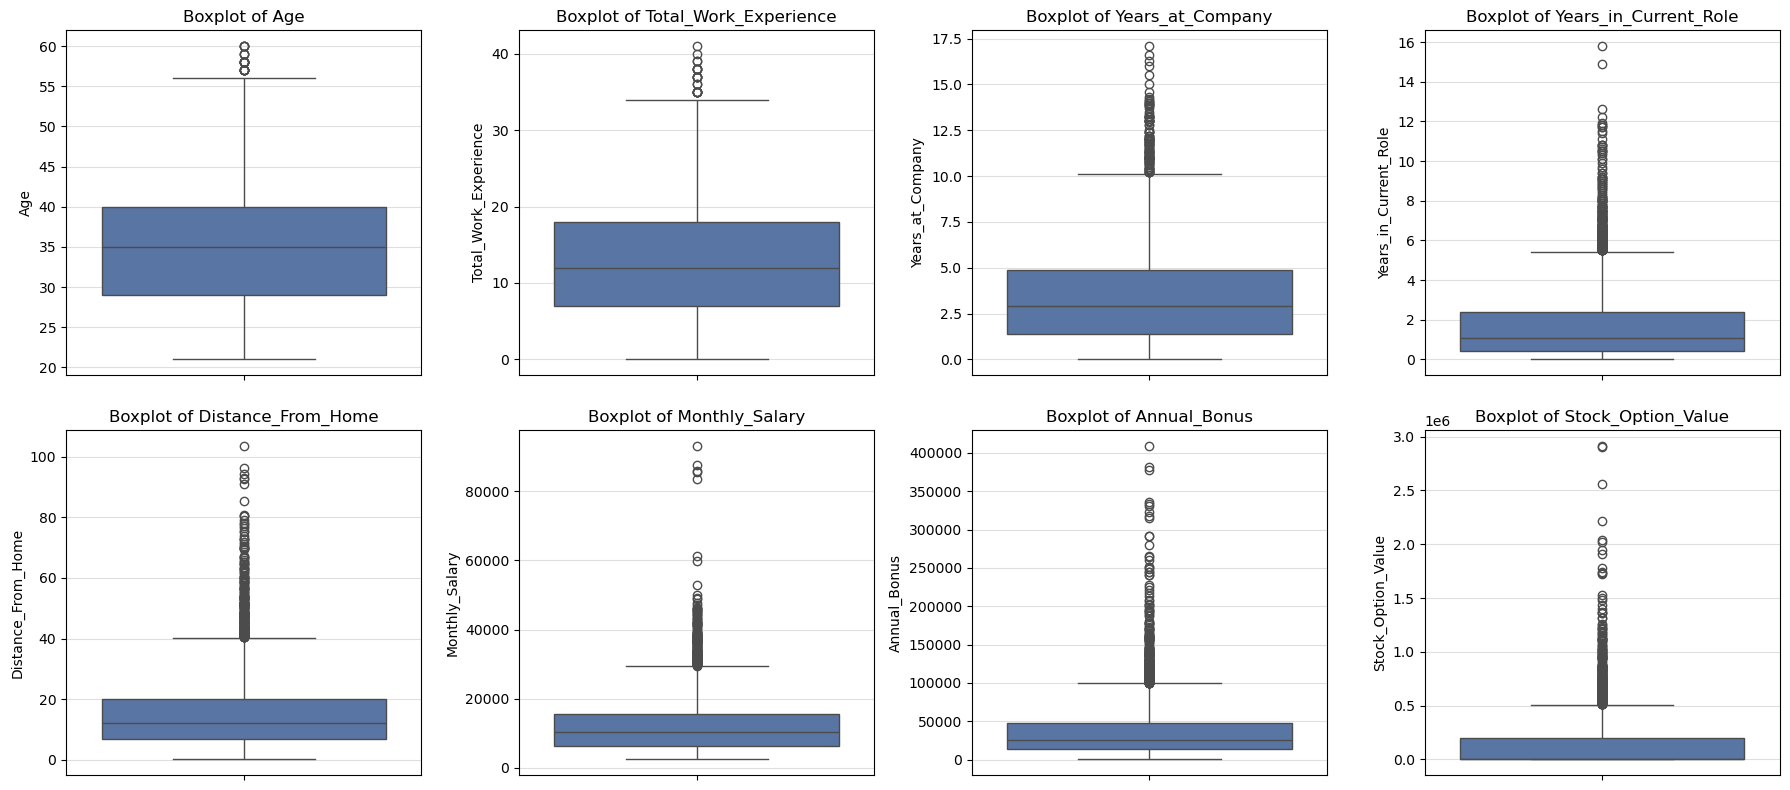

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, boxplt_cols):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(f'Boxplot of {col}')
    ax.grid(axis='y', alpha=0.25, color='gray')
plt.tight_layout()
plt.show()

Outliers are concentrated in the same right-skewed compensation and tenure features identified above. All values remain within plausible business ranges (e.g. `Age` between 21–60, `Distance_From_Home` up to ~103 km for a long commute), so these look like natural skew rather than data entry errors. The IQR rule simply flags the tail of a skewed distribution as "outliers." This means transformation is generally more appropriate here than outright removal or capping, which will be discussed further.

### 1.6 Categorical Feature Distributions

In [12]:
for col in feature_types['Categorical_Nominal'] + feature_types['Categorical_Ordinal']:
    if df[col].dtype == object or df[col].dtype.name == 'str':
        n_unique = df[col].nunique()
        print(f"{col}: {n_unique} categories -> {sorted(df[col].dropna().unique())}")

Gender: 3 categories -> ['Female', 'Male', 'Non-Binary']
Marital_Status: 3 categories -> ['Divorced', 'Married', 'Single']
Department: 7 categories -> ['Engineering', 'Finance', 'HR', 'Marketing', 'Operations', 'Sales', 'Support']
Job_Role: 6 categories -> ['Associate', 'Engineer', 'Lead', 'Manager', 'Senior Engineer', 'Senior Manager']
Business_Travel: 3 categories -> ['Frequently', 'Never', 'Rarely']
Work_Mode: 3 categories -> ['Hybrid', 'Office', 'Remote']
Education_Level: 4 categories -> ['Bachelor', 'Doctorate', 'High School', 'Master']
Compensation_Band: 3 categories -> ['High', 'Low', 'Medium']
Experience_Band: 4 categories -> ['Entry', 'Junior', 'Mid', 'Senior']


All nominal features have low cardinality (3–7 categories), so one-hot encoding is feasible without creating an excessive number of columns. No inconsistent labels (e.g. typos, mixed casing) were found.

### 1.7 Relationship Between Numerical Features and Attrition

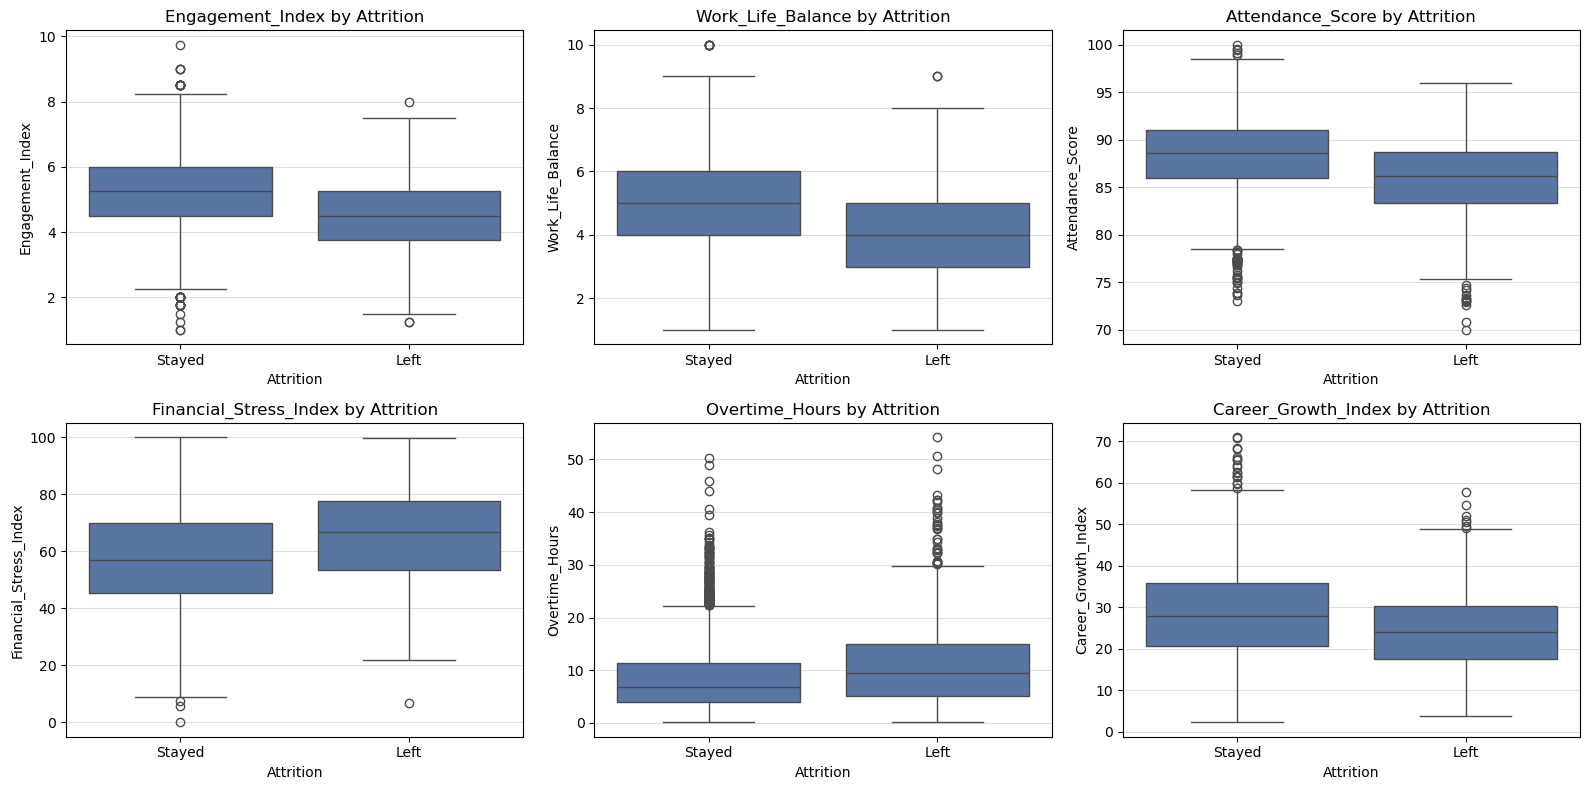

In [13]:
key_features = ['Engagement_Index', 'Work_Life_Balance', 'Attendance_Score', 'Financial_Stress_Index', 'Overtime_Hours', 'Career_Growth_Index']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, key_features):
    sns.boxplot(x='Attrition', y=col, data=df, ax=ax, color='#4C72B0')
    ax.set_xticklabels(['Stayed', 'Left'])
    ax.set_title(f'{col} by Attrition')
    ax.grid(axis='y', alpha=0.25, color='gray')
plt.tight_layout()
plt.show()

Employees who left tend to show **lower** engagement, work-life balance, attendance, and career growth, and **higher** financial stress and overtime hours, an intuitive pattern that matches typical real-world attrition drivers.

### 1.8 Correlation Analysis

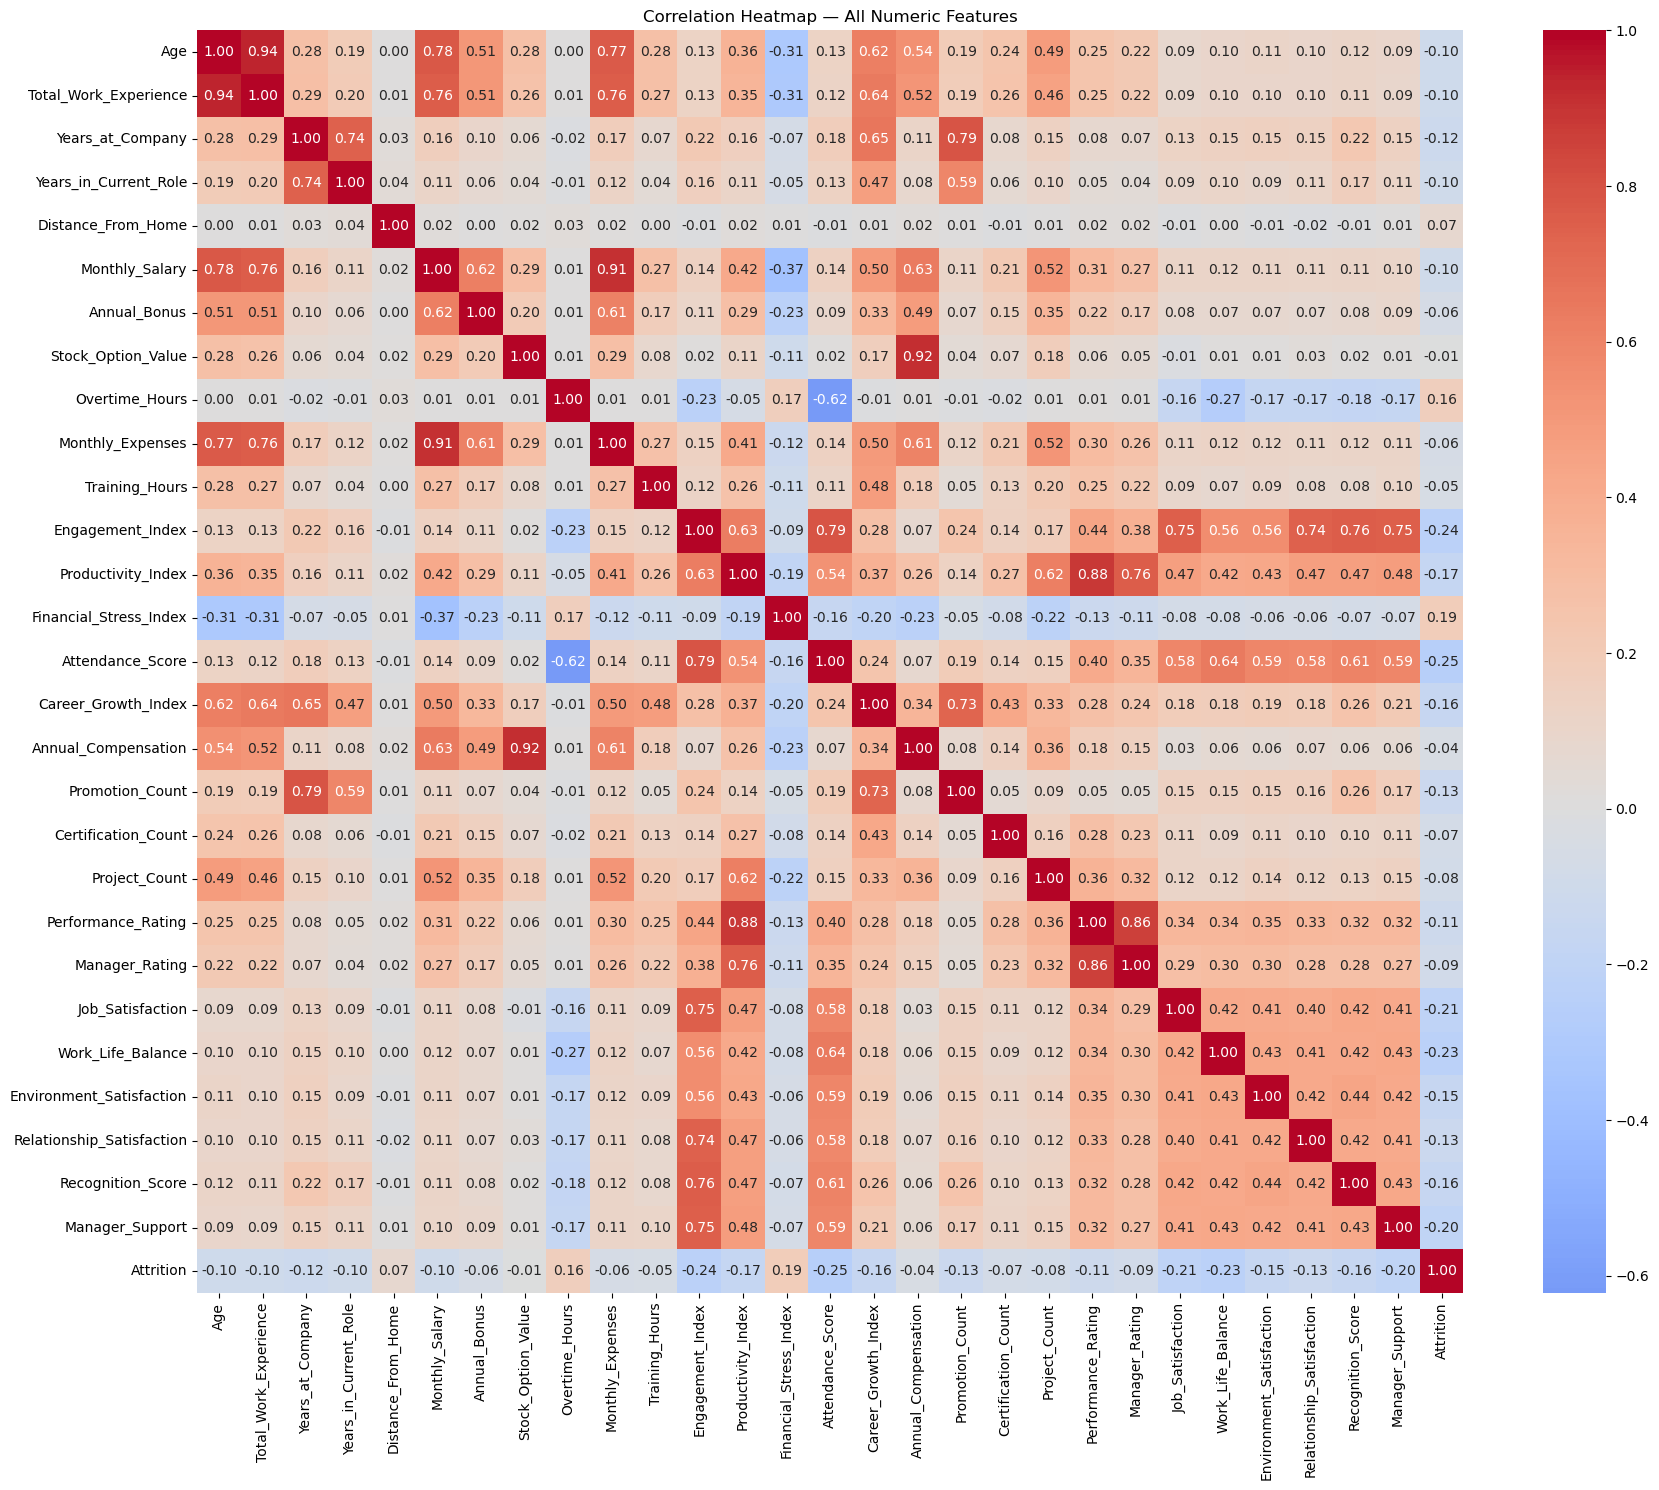

In [14]:
corr_cols = feature_types['Numeric_Continuous'] + feature_types['Numeric_Discrete'] + feature_types['Numeric_Ordinal'] + feature_types['Target']
corr_matrix = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, fmt='.2f', annot=True, ax=ax)
ax.set_title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.show()

Several strongly correlated pairs emerge, e.g. `Age` & `Total_Work_Experience` (r≈0.94), `Stock_Option_Value` & `Annual_Compensation` (r≈0.92), `Monthly_Salary` & `Monthly_Expenses` (r≈0.91), and `Performance_Rating` & `Productivity_Index` (r≈0.88). This signals **multicollinearity** that will need to be addressed through feature selection or dimensionality reduction.

No single numeric feature is strongly correlated with `Attrition` in isolation (the strongest, `Attendance_Score`, is only around -0.25). This suggests attrition is driven by a *combination* of factors rather than one dominant variable

### 1.9 Additional Data Quality Checks

In [15]:
# To check if there's any anomalies in Work experience
print(f"Years_in_Current_Role > Years_at_Company: {(df['Years_in_Current_Role'] > df['Years_at_Company']).sum()} rows")
print(f"Years_at_Company > Total_Work_Experience: {(df['Years_at_Company'] > df['Total_Work_Experience']).sum()} rows")
print()

# Annual Compensation should be a total sum of (Monthly_Salary*12), Annual_Bonus and Stock_Option_Value.
computed = df['Monthly_Salary'] * 12 + df['Annual_Bonus'].fillna(0) + df['Stock_Option_Value']
mask = df['Annual_Bonus'].notna()
max_diff = (computed[mask] - df.loc[mask, 'Annual_Compensation']).abs().max()
print(f"Max absolute difference (non-missing bonus rows): {round(max_diff, 6)}")
print()

# Checking Plausible ranges
print(f"Age range: {df['Age'].min()} - {df['Age'].max()}")
print(f"Distance_From_Home range: {df['Distance_From_Home'].min()} - {df['Distance_From_Home'].max()} km")
print(f"Total_Work_Experience range: {df['Total_Work_Experience'].min()} - {df['Total_Work_Experience'].max()} years")

Years_in_Current_Role > Years_at_Company: 0 rows
Years_at_Company > Total_Work_Experience: 0 rows

Max absolute difference (non-missing bonus rows): 0.0

Age range: 21 - 60
Distance_From_Home range: 0.1 - 103.5 km
Total_Work_Experience range: 0 - 41 years


Key findings from these checks:
- Tenure fields respect the expected ordering (`Years_in_Current_Role` ≤ `Years_at_Company` ≤ `Total_Work_Experience`) in every row.
- `Annual_Compensation` is an exact derived feature (`Monthly_Salary × 12 + Annual_Bonus + Stock_Option_Value`, difference ≈ 0 up to floating-point rounding). It carries no information beyond its three components and is a strong candidate for removal to avoid redundancy.
- All numeric ranges (age, commute distance, experience) fall within plausible real-world bounds, with no negative values or impossible entries.

### 1.10 Summary

- 5,000 employee records, 39 columns. No duplicate rows or duplicate IDs.
- Four columns have missing values in the 5–7% range: Moderate and imputable, no column needs to be dropped.
- Compensation-related features and several tenure/count features are highly right-skewed, driving most of the IQR-flagged "outliers." These values are business-plausible, so transformation (e.g. log) is preferred over deletion.
- `Annual_Compensation` is an exact linear function of `Monthly_Salary`, `Annual_Bonus`, and `Stock_Option_Value` — a redundant feature.
- Several other pairs are highly correlated (`Age` & `Total_Work_Experience`; `Performance_Rating` & `Productivity_Index`/`Manager_Rating`; `Monthly_Salary` & `Monthly_Expenses`), signalling the need for feature selection or dimensionality reduction later.
- No single numeric feature correlates strongly with `Attrition` in isolation. 
- All categorical columns have low cardinality (3–7 levels) with clean, consistent labels.

Next Steps: Impute the four missing-value columns, log-transform the skewed features, encode categorical variables appropriately, and drop redundant features before modelling.

## 2. Designing a Feature Engineering Strategy

Building on the observations from Part A, this section applies a concrete preprocessing pipeline to the dataset:
1. Handle missing values.
2. Encode categorical variables.
3. Transform skewed numerical features.
4. Scale numeric features.

Every step below is applied to a working copy `df_fe`, which becomes the feature-engineered dataset carried forward into next section.

### 2.1 Handling Missing Values

**Choice of imputation value:**
- `Manager_Rating` (1–5) and `Environment_Satisfaction` (1–10) are ordinalrating scales. The median is guaranteed to land on a real category value
  (e.g. 3.0, 5.0), whereas the mean could produce a fractional value (e.g. 3.4) that doesn't correspond to any actual rating.
- `Training_Hours` is close to symmetric (skew ≈ 0), so median ≈ mean, median is used for consistency.
- `Annual_Bonus` is highly right-skewed, where the median is far more robust to extreme high earners than the mean.

In [16]:
df_fe = df.copy()  # working copy of the dataset

impute_cols = ['Training_Hours', 'Annual_Bonus', 'Manager_Rating', 'Environment_Satisfaction']
impute_values = {}
for col in impute_cols:
    median_val = df_fe[col].median()
    impute_values[col] = median_val
    df_fe[col] = df_fe[col].fillna(median_val)

print("Imputation values used (median):")
for col, val in impute_values.items():
    print(f"{col}: {val}")

print("\nTotal missing values in dataset:", df_fe.isnull().sum().sum())

Imputation values used (median):
Training_Hours: 27.1
Annual_Bonus: 25993.18
Manager_Rating: 3.0
Environment_Satisfaction: 5.0

Total missing values in dataset: 0


### 2.2 Encoding Categorical Variables

Nominal features are one-hot encoded, while ordinal features are mapped to integers that preserve that order.

`Business_Travel` (`Never` / `Rarely` / `Frequently`) has a natural order by travel frequency, so it's worth checking whether that order is reflected in the data before deciding how to encode it.

In [17]:
print("Attrition rate by Business_Travel:")
print(df.groupby('Business_Travel', observed=True)['Attrition'].mean().round(3).sort_values())

Attrition rate by Business_Travel:
Business_Travel
Frequently    0.185
Never         0.189
Rarely        0.196
Name: Attrition, dtype: float64


Attrition barely varies across the three travel categories so there's no meaningful trend to justify imposing an ordinal structure. Treating it as nominal avoids implying a false linear relationship the data doesn't support. 

In [18]:
ordinal_maps = {'Education_Level': ['High School', 'Bachelor', 'Master', 'Doctorate'], 
                'Compensation_Band': ['Low', 'Medium', 'High'], 
                'Experience_Band': ['Entry', 'Junior', 'Mid', 'Senior']}

for col, order in ordinal_maps.items():
    mapping = {level: i for i, level in enumerate(order)}
    df_fe[col] = df_fe[col].map(mapping)
    print(f"{col}: {mapping}")

Education_Level: {'High School': 0, 'Bachelor': 1, 'Master': 2, 'Doctorate': 3}
Compensation_Band: {'Low': 0, 'Medium': 1, 'High': 2}
Experience_Band: {'Entry': 0, 'Junior': 1, 'Mid': 2, 'Senior': 3}


In [19]:
nominal_cols = ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Business_Travel', 'Work_Mode']
df_fe = pd.get_dummies(df_fe, columns=nominal_cols, prefix=nominal_cols, drop_first=True)

new_dummy_cols = [c for c in df_fe.columns if any(c.startswith(n + '_') for n in nominal_cols)]
df_fe[new_dummy_cols] = df_fe[new_dummy_cols].astype(int)  # 0/1 int rather than True/False for a uniformly numeric dataset

print(f"Shape after one-hot encoding: {df_fe.shape}")
print(f"\n{len(new_dummy_cols)} dummy columns created:")
print(new_dummy_cols)

Shape after one-hot encoding: (5000, 52)

19 dummy columns created:
['Gender_Male', 'Gender_Non-Binary', 'Marital_Status_Married', 'Marital_Status_Single', 'Department_Finance', 'Department_HR', 'Department_Marketing', 'Department_Operations', 'Department_Sales', 'Department_Support', 'Job_Role_Engineer', 'Job_Role_Lead', 'Job_Role_Manager', 'Job_Role_Senior Engineer', 'Job_Role_Senior Manager', 'Business_Travel_Never', 'Business_Travel_Rarely', 'Work_Mode_Office', 'Work_Mode_Remote']


`drop_first=True` drops one category per feature (e.g. `Gender_Female` is implied when both `Gender_Male` and `Gender_Non-Binary` are 0). This
avoids the perfect multicollinearity between a feature's dummy columns.

### 2.3 Transforming Skewed Numerical Features

Rather than removing the "outliers" that drive this skew, we apply a **log1p transform** (`log(1 + x)`), which:
- Compresses long right tails, pulling extreme high values in.
- Is defined at `x = 0` (unlike a plain `log`), which matters for zero-inflated columns like `Stock_Option_Value` and count features like `Promotion_Count`.
- Is simple, monotonic (preserves rank order), and easily invertible (`expm1`) if the original scale is ever needed again.

In [20]:
candidate_cols = feature_types['Numeric_Continuous'] + feature_types['Numeric_Discrete']
transform_cols = [c for c in candidate_cols if abs(df_fe[c].skew()) > 1]
print(f"Columns selected for log1p transform (|skew| > 1): {len(transform_cols)}")

skew_before = df_fe[transform_cols].skew()
for col in transform_cols:
    df_fe[col] = np.log1p(df_fe[col])
skew_after = df_fe[transform_cols].skew()

skew_compare = pd.DataFrame({'Skew_Before': skew_before.round(3),'Skew_After': skew_after.round(3),}).sort_values('Skew_Before', ascending=False)
skew_compare

Columns selected for log1p transform (|skew| > 1): 11


,Skew_Before,Skew_After
Stock_Option_Value,3.380,0.407
Annual_Bonus,3.185,-0.376
Annual_Compensation,2.164,0.098
Monthly_Salary,2.143,0.047
Years_in_Current_Role,1.924,0.447
Distance_From_Home,1.895,-0.259
Overtime_Hours,1.611,-0.183
Monthly_Expenses,1.601,-0.008
Certification_Count,1.386,0.467
Years_at_Company,1.152,-0.318


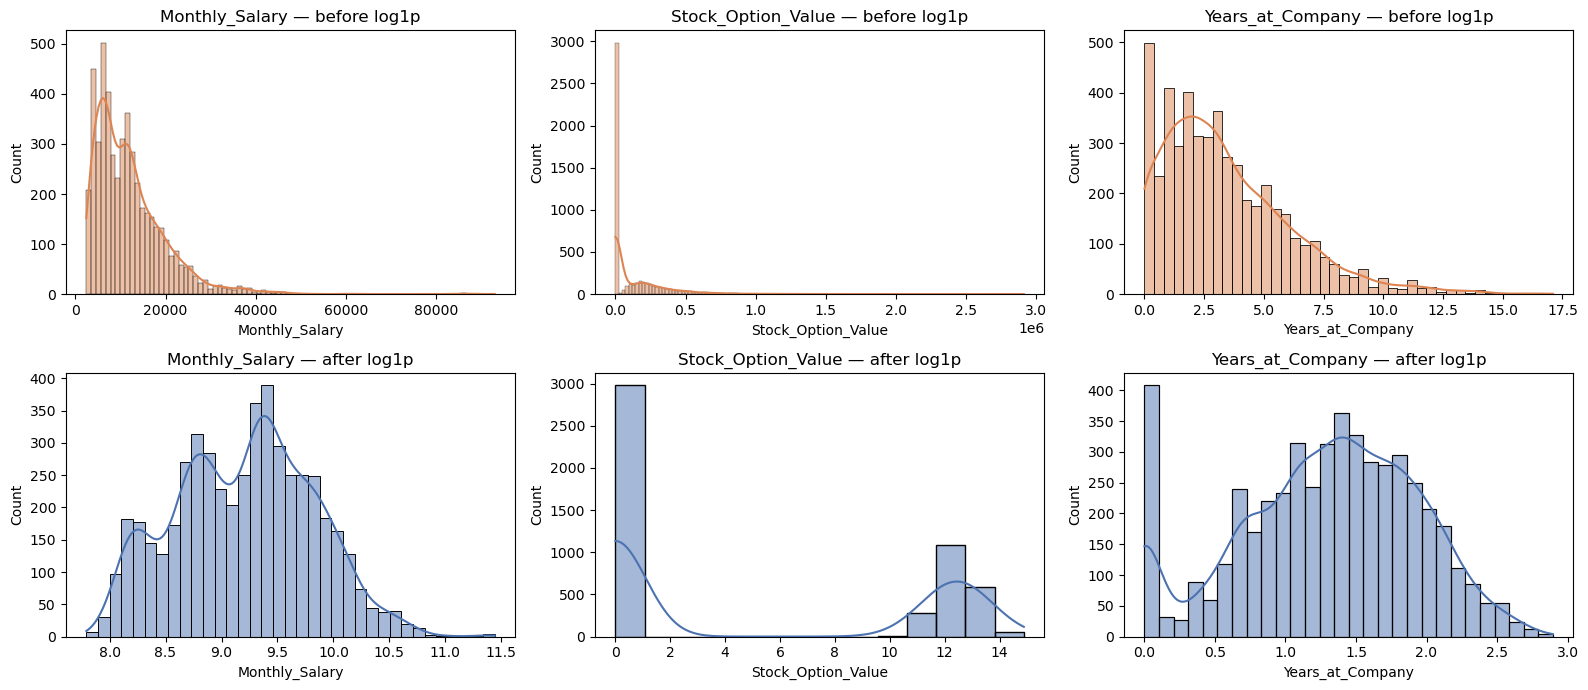

In [21]:
example_cols = ['Monthly_Salary', 'Stock_Option_Value', 'Years_at_Company']
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for i, col in enumerate(example_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i], color='#DD8452')
    axes[0, i].set_title(f'{col} — before log1p')
    sns.histplot(df_fe[col], kde=True, ax=axes[1, i], color='#4C72B0')
    axes[1, i].set_title(f'{col} — after log1p')
plt.tight_layout()
plt.show()

The transform brings every selected column's |skew| down to well under 0.5, and the histograms confirm the shapes are now much closer to symmetric/bell-shaped.

### 2.4 Feature Scaling

Continuous, count, and ordinal numeric features are all on very different native scales (e.g. `Monthly_Salary` in the thousands vs. `Job_Satisfaction`
from 1–10). Left unscaled, high-magnitude features like salary would dominate distance-based methods, regularized linear models, and PCA simply because of their units, not because they're more important. We apply `StandardScaler` (zero mean, unit variance) to put every numeric feature on a comparable footing.

One-hot dummy columns (already 0/1) and the target `Attrition` are excluded from scaling because scaling a binary indicator doesn't add information and would just make it harder to interpret.

In [22]:
from sklearn.preprocessing import StandardScaler

scale_cols = [c for c in (feature_types['Numeric_Continuous'] + feature_types['Numeric_Discrete'] + feature_types['Categorical_Ordinal']) if c in df_fe.columns]

scaler = StandardScaler()
df_fe[scale_cols] = scaler.fit_transform(df_fe[scale_cols])

print(f"Scaled {len(scale_cols)} numeric columns to zero mean / unit variance.")
df_fe[scale_cols].agg(['mean', 'std']).T.round(2).head(10)

Scaled 31 numeric columns to zero mean / unit variance.


,mean,std
Age,0.0,1.0
Total_Work_Experience,-0.0,1.0
Years_at_Company,0.0,1.0
Years_in_Current_Role,0.0,1.0
Distance_From_Home,-0.0,1.0
Monthly_Salary,-0.0,1.0
Annual_Bonus,0.0,1.0
Stock_Option_Value,0.0,1.0
Overtime_Hours,0.0,1.0
Monthly_Expenses,-0.0,1.0


### 2.5 Final Cleanup

In [23]:
employee_ids = df_fe['Employee_ID']  # kept aside for traceability, not used as a model feature
df_fe = df_fe.drop(columns=['Employee_ID'])

non_numeric_cols = df_fe.select_dtypes(exclude='number').columns.tolist()
print(f"Final cleaned dataset shape: {df_fe.shape}")
print(f"All remaining columns are numeric: {len(non_numeric_cols) == 0}")
print(f"Remaining missing values: {df_fe.isnull().sum().sum()}")
df_fe.head()

Final cleaned dataset shape: (5000, 51)
All remaining columns are numeric: True
Remaining missing values: 0


,Age,Education_Level,Total_Work_Experience,Years_at_Company,Years_in_Current_Role,Promotion_Count,Distance_From_Home,Monthly_Salary,Annual_Bonus,Stock_Option_Value,Overtime_Hours,Monthly_Expenses,Compensation_Band,Performance_Rating,Manager_Rating,Training_Hours,Certification_Count,Project_Count,Job_Satisfaction,Work_Life_Balance,Environment_Satisfaction,Relationship_Satisfaction,Recognition_Score,Manager_Support,Engagement_Index,Productivity_Index,Financial_Stress_Index,Attendance_Score,Career_Growth_Index,Annual_Compensation,Experience_Band,Attrition,Gender_Male,Gender_Non-Binary,Marital_Status_Married,Marital_Status_Single,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,Department_Support,Job_Role_Engineer,Job_Role_Lead,Job_Role_Manager,Job_Role_Senior Engineer,Job_Role_Senior Manager,Business_Travel_Never,Business_Travel_Rarely,Work_Mode_Office,Work_Mode_Remote
0,0.262229,-0.354264,0.292924,1.372727,1.664685,1.660542,0.631190,0.170485,-0.385669,1.127450,-0.516551,-0.078403,0.000000,0.807406,0.766734,1.700208,1.89265,-0.708518,0.610425,0.159128,1.297757,0.624000,1.153752,1.252029,1.212891,0.613959,-0.917648,1.223461,2.399396,0.396071,0.445764,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,-1.035165,-0.354264,-1.341274,-0.304612,-1.228045,-0.862848,-0.768468,-0.829544,-0.588433,-0.821154,0.569392,-0.428205,-1.224622,-0.352327,-0.307424,-0.011886,-0.96103,-1.418884,0.610425,0.159128,-0.006259,-0.003262,-0.074951,-0.009970,0.175452,-0.426786,1.608679,0.066335,-1.279440,-1.003113,-1.557670,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0
2,0.781187,0.964664,0.292924,0.695822,-1.079676,0.729234,-1.016305,1.293531,-0.255161,1.197239,-1.871018,1.078048,1.224622,-0.352327,0.766734,0.993969,-0.96103,1.067395,0.610425,-0.447306,0.645749,-0.630523,2.382454,-0.640969,0.590427,0.319914,-1.400274,0.686135,0.796461,0.997205,0.445764,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,1.040666,-0.354264,1.298584,0.143787,-0.388290,-0.862848,0.319163,1.623628,1.888928,1.077839,-1.871018,1.753180,1.224622,0.807406,1.840892,0.951167,-0.96103,1.067395,0.610425,0.765563,-0.006259,0.624000,0.539400,1.883029,1.212891,1.076030,-0.516576,0.353742,0.389291,1.113819,1.447481,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,-1.813601,-0.354264,-1.592690,-2.016978,-1.390565,-0.862848,0.376483,-1.809215,-1.946082,-0.821154,-0.902885,-2.126253,-1.224622,-0.352327,-0.307424,-1.445765,-0.96103,-1.063701,-0.007039,-0.447306,-0.006259,-0.630523,-0.074951,-0.640969,-0.447012,-0.419543,-0.882349,0.516190,-1.286115,-1.768473,-1.557670,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0


### 2.6 Summary

- Missing values were handled using median imputation, as it guarantees valid values for ordinal scales while being robust for the skewed Annual_Bonus.
- `Education_Level`, `Compensation_Band`, and `Experience_Band` were ordinal encoded using integer mapping in domain-defined order, since this preserves their inherent ranking, with the order cross-validated against related numeric variables where applicable.
- `Gender`, `Marital_Status`, `Department`, `Job_Role`, `Business_Travel`, and `Work_Mode` were nominally encoded using one-hot encoding with drop_first=True, since these variables have no inherent order (confirmed empirically for Business_Travel), their low cardinality keeps dimensionality manageable, and drop_first avoids the multicollinearity.
- 11 highly skewed numeric columns (|skew| > 1) were corrected using a log1p transform, which reduced all target columns to |skew| < 0.55, is safe at zero for zero-inflated/count features, and remains simple and invertible.
- All continuous, count, and ordinal numeric columns were scaled using StandardScaler, putting features with very different native units (e.g. salary vs. 1–10 ratings) on a comparable scale for later modelling.
- Employee_ID was dropped from the feature set (kept aside for reference) since it is unique per row and carries no predictive signal.

At the end of Part B, df_fe has 5,000 rows and the transformed/encoded column set, contains no missing values, and is entirely numeric.

## 3. Feature Construction & Feature Selection

This section engineers a small set of business-motivated features on top of the cleaned dataset, and formally tests the entire feature pool for redundancy, dropping what doesn't add information. Both steps continue to build on `df_fe`.

### 3.1 Feature Construction

The five features below are computed from the **original, untransformed** values in `df` rather than the already log-transformed/scaled columns in
`df_fe`. This matters for interpretability: a ratio like "pay per year ofexperience" should be computed from real salary and real years, not z-scores.
Each new feature is then run through the same log-transform-if-skewed + scale treatment used in Part 2 so it integrates cleanly into the pipeline.

| Feature | Formula | Business Intuition |
|---|---|---|
| `Has_Stock_Options` | `Stock_Option_Value > 0` | Separates employees with *no* equity from those with some. Equity participation may act as a retention lever independent of the amount granted. |
| `Role_Stability_Ratio` | `Years_in_Current_Role / (Years_at_Company + 1)` | Share of company tenure spent in the current role. A ratio near 1 means no recent role change/promotion which is a plausible stagnation signal. |
| `Compensation_Per_Experience_Year` | `Annual_Compensation / (Total_Work_Experience + 1)` | Pay relative to career experience. Employees paid low relative to their experience may be more attrition-prone. |
| `Burnout_Risk_Score` | `Overtime_Hours / (Work_Life_Balance + 1)` | Combines heavy overtime with poor work-life balance into one compounded-strain score, capturing an interaction neither variable shows alone. |
| `Promotion_Velocity` | `Promotion_Count / (Years_at_Company + 1)` | Promotions earned per year of tenure, a growth-*pace* signal, distinct from the raw count, which ignores how long the employee has had to earn them. |

Every denominator uses `+ 1` to avoid dividing by zero for the employees with `Years_at_Company == 0` (all of whom also have `Years_in_Current_Role
== 0` and `Promotion_Count == 0`).

In [24]:
df_fe['Has_Stock_Options'] = (df['Stock_Option_Value'] > 0).astype(int)
df_fe['Role_Stability_Ratio'] = df['Years_in_Current_Role'] / (df['Years_at_Company'] + 1)
df_fe['Compensation_Per_Experience_Year'] = df['Annual_Compensation'] / (df['Total_Work_Experience'] + 1)
df_fe['Burnout_Risk_Score'] = df['Overtime_Hours'] / (df['Work_Life_Balance'] + 1)
df_fe['Promotion_Velocity'] = df['Promotion_Count'] / (df['Years_at_Company'] + 1)

new_features = ['Has_Stock_Options', 'Role_Stability_Ratio', 'Compensation_Per_Experience_Year', 'Burnout_Risk_Score', 'Promotion_Velocity']
df_fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Has_Stock_Options,5000.0,0.404000,0.490747,0.000000,0.000000,0.000000,1.000000,1.000000e+00
Role_Stability_Ratio,5000.0,0.331372,0.236873,0.000000,0.125000,0.310345,0.518519,9.218750e-01
Compensation_Per_Experience_Year,5000.0,30228.634548,53943.075091,4006.977500,11162.225446,18849.212222,33289.289415,1.503003e+06
Burnout_Risk_Score,5000.0,1.876081,2.043780,0.016667,0.683333,1.260000,2.351389,2.405000e+01
Promotion_Velocity,5000.0,0.101482,0.119810,0.000000,0.000000,0.000000,0.217391,3.333333e-01


In [25]:
# Checking skewness to determine any potential need for log transformation
print("Skewness of new features:")
print(df_fe[new_features].skew().round(2))

# Checking correlation with our Target Variable
print("\nCorrelation with Attrition:")
print(df_fe[new_features].corrwith(df_fe['Attrition']).round(3))

Skewness of new features:
Has_Stock_Options                    0.39
Role_Stability_Ratio                 0.29
Compensation_Per_Experience_Year    13.20
Burnout_Risk_Score                   3.60
Promotion_Velocity                   0.56
dtype: float64

Correlation with Attrition:
Has_Stock_Options                  -0.037
Role_Stability_Ratio               -0.069
Compensation_Per_Experience_Year    0.032
Burnout_Risk_Score                  0.225
Promotion_Velocity                 -0.109
dtype: float64


**Interpretation:**
- `Burnout_Risk_Score` shows the strongest link to `Attrition` of any feature built so far (≈0.22) which is on par with the strongest single feature found in Part 1 (`Attendance_Score`, ≈-0.25).
- `Compensation_Per_Experience_Year` is **severely right-skewed (≈13)** — far more than anything seen in Part B. This turns out to be driven by a small number of employees with `Total_Work_Experience == 0` but very large stock grants, which makes the ratio explode for a near-zero denominator. This is a real risk of ratio features and is worth correcting with a transform rather than discarding the feature outright.

In [26]:
right_skewed_new = [c for c in new_features if c != 'Has_Stock_Options' and abs(df_fe[c].skew()) > 1]
print("New features requiring log1p (|skew| > 1):", right_skewed_new)

skew_before_new = df_fe[right_skewed_new].skew()
for col in right_skewed_new:
    df_fe[col] = np.log1p(df_fe[col])
skew_after_new = df_fe[right_skewed_new].skew()

pd.DataFrame({'Skew_Before': skew_before_new.round(3), 'Skew_After': skew_after_new.round(3)})

New features requiring log1p (|skew| > 1): ['Compensation_Per_Experience_Year', 'Burnout_Risk_Score']


,Skew_Before,Skew_After
Compensation_Per_Experience_Year,13.196,0.794
Burnout_Risk_Score,3.595,0.872


In [27]:
new_numeric_features = ['Role_Stability_Ratio', 'Compensation_Per_Experience_Year', 'Burnout_Risk_Score', 'Promotion_Velocity']
new_scaler = StandardScaler()
df_fe[new_numeric_features] = new_scaler.fit_transform(df_fe[new_numeric_features])

print(f"Scaled {len(new_numeric_features)} new numeric features ('Has_Stock_Options' left as 0/1, like the one-hot columns).")
df_fe[new_features].agg(['mean', 'std']).T.round(2)

Scaled 4 new numeric features ('Has_Stock_Options' left as 0/1, like the one-hot columns).


,mean,std
Has_Stock_Options,0.4,0.49
Role_Stability_Ratio,-0.0,1.00
Compensation_Per_Experience_Year,-0.0,1.00
Burnout_Risk_Score,-0.0,1.00
Promotion_Velocity,0.0,1.00


### 3.2 Feature Selection

With the new features in place, the full numeric/ordinal pool is checked for redundancy using the **Variance Inflation Factor (VIF)**: It measures how much variance of a regression coefficient is inflated due to multicollinearity among independent variables.

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(data, cols):
    X = data[cols].values.astype(float)
    vif_df = pd.DataFrame({'Feature': cols,'VIF': [variance_inflation_factor(X, i) for i in range(len(cols))]})
    return vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

numeric_ordinal_cols = scale_cols + new_features  # scale_cols is the Part 2 continuous+discrete+ordinal list
numeric_ordinal_cols = [c for c in numeric_ordinal_cols if c in df_fe.columns]

vif_initial = compute_vif(df_fe, numeric_ordinal_cols)
vif_initial.head(10)

,Feature,VIF
0,Recognition_Score,inf
1,Job_Satisfaction,inf
2,Engagement_Index,inf
3,Relationship_Satisfaction,inf
4,Manager_Support,inf
5,Monthly_Salary,55.852162
6,Monthly_Expenses,51.930899
7,Promotion_Count,30.746548
8,Years_in_Current_Role,30.593077
9,Total_Work_Experience,26.577077


Several features show **infinite VIF**, an exact linear dependency. `Annual_Compensation` is already known to be an exact function of `Monthly_Salary`, `Annual_Bonus`, and `Stock_Option_Value`. But `Engagement_Index`, `Job_Satisfaction`, `Relationship_Satisfaction`, `Recognition_Score`, and `Manager_Support` all showing infinite VIF together is new and worth checking directly.

In [29]:
# Determining whether the Engagement_Index is average value of other four parameters
computed_engagement = df[['Job_Satisfaction', 'Relationship_Satisfaction', 'Recognition_Score', 'Manager_Support']].mean(axis=1)
max_diff = (computed_engagement - df['Engagement_Index']).abs().max()

print("Max absolute difference:", max_diff)

Max absolute difference: 0.0


This confirms it that `Engagement_Index` is an **exact average** of four other survey columns (note it does *not* include `Work_Life_Balance` or
`Environment_Satisfaction`, which stay independent). It carries no information beyond its four ingredients, exactly mirroring the `Annual_Compensation` situation. Both derived composites are dropped, keeping the more granular raw components.

In [30]:
known_redundant = ['Annual_Compensation', 'Engagement_Index']
df_fe = df_fe.drop(columns=known_redundant)
vif_pool = [c for c in numeric_ordinal_cols if c not in known_redundant]

vif_table = compute_vif(df_fe, vif_pool)
vif_table

,Feature,VIF
0,Monthly_Salary,52.262601
1,Monthly_Expenses,51.374655
2,Promotion_Count,30.560149
3,Years_in_Current_Role,28.652637
4,Total_Work_Experience,26.382981
5,Productivity_Index,21.164511
6,Burnout_Risk_Score,20.421172
7,Career_Growth_Index,17.848767
8,Role_Stability_Ratio,16.512346
9,Age,15.928645


Removing the two exact composites resolves the infinite VIFs, but several features are still highly redundant. Rather than removing these by hand, the same VIF rule is applied iteratively: recompute VIF, drop the single worst offender, and repeat until every remaining feature has VIF ≤ 10.

In [31]:
VIF_THRESHOLD = 10
cols = vif_pool[:]
elimination_log = []

while True:
    vif_table = compute_vif(df_fe, cols)
    worst = vif_table.iloc[0]
    if worst['VIF'] <= VIF_THRESHOLD:
        break
    elimination_log.append({'Dropped_Feature': worst['Feature'], 'VIF_at_removal': round(worst['VIF'], 2)})
    cols.remove(worst['Feature'])

elimination_df = pd.DataFrame(elimination_log)
print(f"Features dropped for VIF > {VIF_THRESHOLD} (in removal order):")
elimination_df

Features dropped for VIF > 10 (in removal order):


,Dropped_Feature,VIF_at_removal
0,Monthly_Salary,52.26
1,Promotion_Count,30.55
2,Total_Work_Experience,25.54
3,Years_in_Current_Role,22.65
4,Productivity_Index,21.16
5,Burnout_Risk_Score,20.28


In [32]:
final_vif = compute_vif(df_fe, cols)
print(f"All {len(cols)} remaining features now have VIF <= {VIF_THRESHOLD}:")
final_vif

All 28 remaining features now have VIF <= 10:


,Feature,VIF
0,Monthly_Expenses,9.784104
1,Career_Growth_Index,8.944614
2,Age,8.637066
3,Experience_Band,6.945417
4,Attendance_Score,6.837995
5,Compensation_Band,6.037196
6,Stock_Option_Value,4.736725
7,Performance_Rating,4.072434
8,Compensation_Per_Experience_Year,3.920795
9,Manager_Rating,3.414243


None of this information is actually lost as each dropped feature's concept remains represented by something else in the dataset which can be something it highly correlates with, something which is better defined by our newly engineered features or something which better represented by its source columns ( Our own engineered feature `Burnout_Rish_Score`, which was removed due to having greater VIF than the threshold, is better represented by `Overtime_Hours` and `Work_Life_Balance`).

Testing engineered features for redundancy (rather than assuming anything constructed is automatically worth keeping) is exactly the point of doing feature selection after feature construction.


In [33]:
dropped_by_vif = elimination_df['Dropped_Feature'].tolist()
df_fe = df_fe.drop(columns=dropped_by_vif)

print(f"Final dataset shape: {df_fe.shape}")
df_fe.head()

Final dataset shape: (5000, 48)


,Age,Education_Level,Years_at_Company,Distance_From_Home,Annual_Bonus,Stock_Option_Value,Overtime_Hours,Monthly_Expenses,Compensation_Band,Performance_Rating,Manager_Rating,Training_Hours,Certification_Count,Project_Count,Job_Satisfaction,Work_Life_Balance,Environment_Satisfaction,Relationship_Satisfaction,Recognition_Score,Manager_Support,Financial_Stress_Index,Attendance_Score,Career_Growth_Index,Experience_Band,Attrition,Gender_Male,Gender_Non-Binary,Marital_Status_Married,Marital_Status_Single,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,Department_Support,Job_Role_Engineer,Job_Role_Lead,Job_Role_Manager,Job_Role_Senior Engineer,Job_Role_Senior Manager,Business_Travel_Never,Business_Travel_Rarely,Work_Mode_Office,Work_Mode_Remote,Has_Stock_Options,Role_Stability_Ratio,Compensation_Per_Experience_Year,Promotion_Velocity
0,0.262229,-0.354264,1.372727,0.631190,-0.385669,1.127450,-0.516551,-0.078403,0.000000,0.807406,0.766734,1.700208,1.89265,-0.708518,0.610425,0.159128,1.297757,0.624000,1.153752,1.252029,-0.917648,1.223461,2.399396,0.445764,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0.999831,-0.106200,1.050028
1,-1.035165,-0.354264,-0.304612,-0.768468,-0.588433,-0.821154,0.569392,-0.428205,-1.224622,-0.352327,-0.307424,-0.011886,-0.96103,-1.418884,0.610425,0.159128,-0.006259,-0.003262,-0.074951,-0.009970,1.608679,0.066335,-1.279440,-1.557670,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,-1.258349,0.435354,-0.847110
2,0.781187,0.964664,0.695822,-1.016305,-0.255161,1.197239,-1.871018,1.078048,1.224622,-0.352327,0.766734,0.993969,-0.96103,1.067395,0.610425,-0.447306,0.645749,-0.630523,2.382454,-0.640969,-1.400274,0.686135,0.796461,0.445764,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,-1.250942,0.589470,0.617347
3,1.040666,-0.354264,0.143787,0.319163,1.888928,1.077839,-1.871018,1.753180,1.224622,0.807406,1.840892,0.951167,-0.96103,1.067395,0.610425,0.765563,-0.006259,0.624000,0.539400,1.883029,-0.516576,0.353742,0.389291,1.447481,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,-0.554667,0.201042,-0.847110
4,-1.813601,-0.354264,-2.016978,0.376483,-1.946082,-0.821154,-0.902885,-2.126253,-1.224622,-0.352327,-0.307424,-1.445765,-0.96103,-1.063701,-0.007039,-0.447306,-0.006259,-0.630523,-0.074951,-0.640969,-0.882349,0.516190,-1.286115,-1.557670,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1.399086,0.967726,-0.847110


### 3.3 Summary

- Constructed Features: `Has_Stock_Options`, `Role_Stability_Ratio`, `Compensation_Per_Experience_Year`, `Burnout_Risk_Score`, `Promotion_Velocity` — each targets a specific business hypothesis (equity participation, role stagnation, pay equity, burnout, growth pace) not directly captured by any single raw column.

- Removed as redundant: Exact derived features (`Annual_Compensation`, `Engagement_Index`), and High VIF features (> 10) iteratively removed (`Stock_Option_Value`, `Monthly_Salary`, `Promotion_Count`, `Total_Work_Experience`, `Years_in_Current_Role`, `Productivity_Index`, and our own `Burnout_Risk_Score`).

- Result: The dataset shrinks from 51 columns to 47 columns, despite adding 5 new engineered features.

## 4. Dimensionality Reduction & Pipeline Design

Two things happen here, first assess whether dimensionality reduction is actually warranted on top of feature selection, and apply it where
justified and secondly, consolidate every step from Parts 2-4 into a single reusable `scikit-learn` pipeline that can be `fit` on training data and transformed onto new data without repeating any manual work.

### 4.1 Assessing Dimensionality Reduction

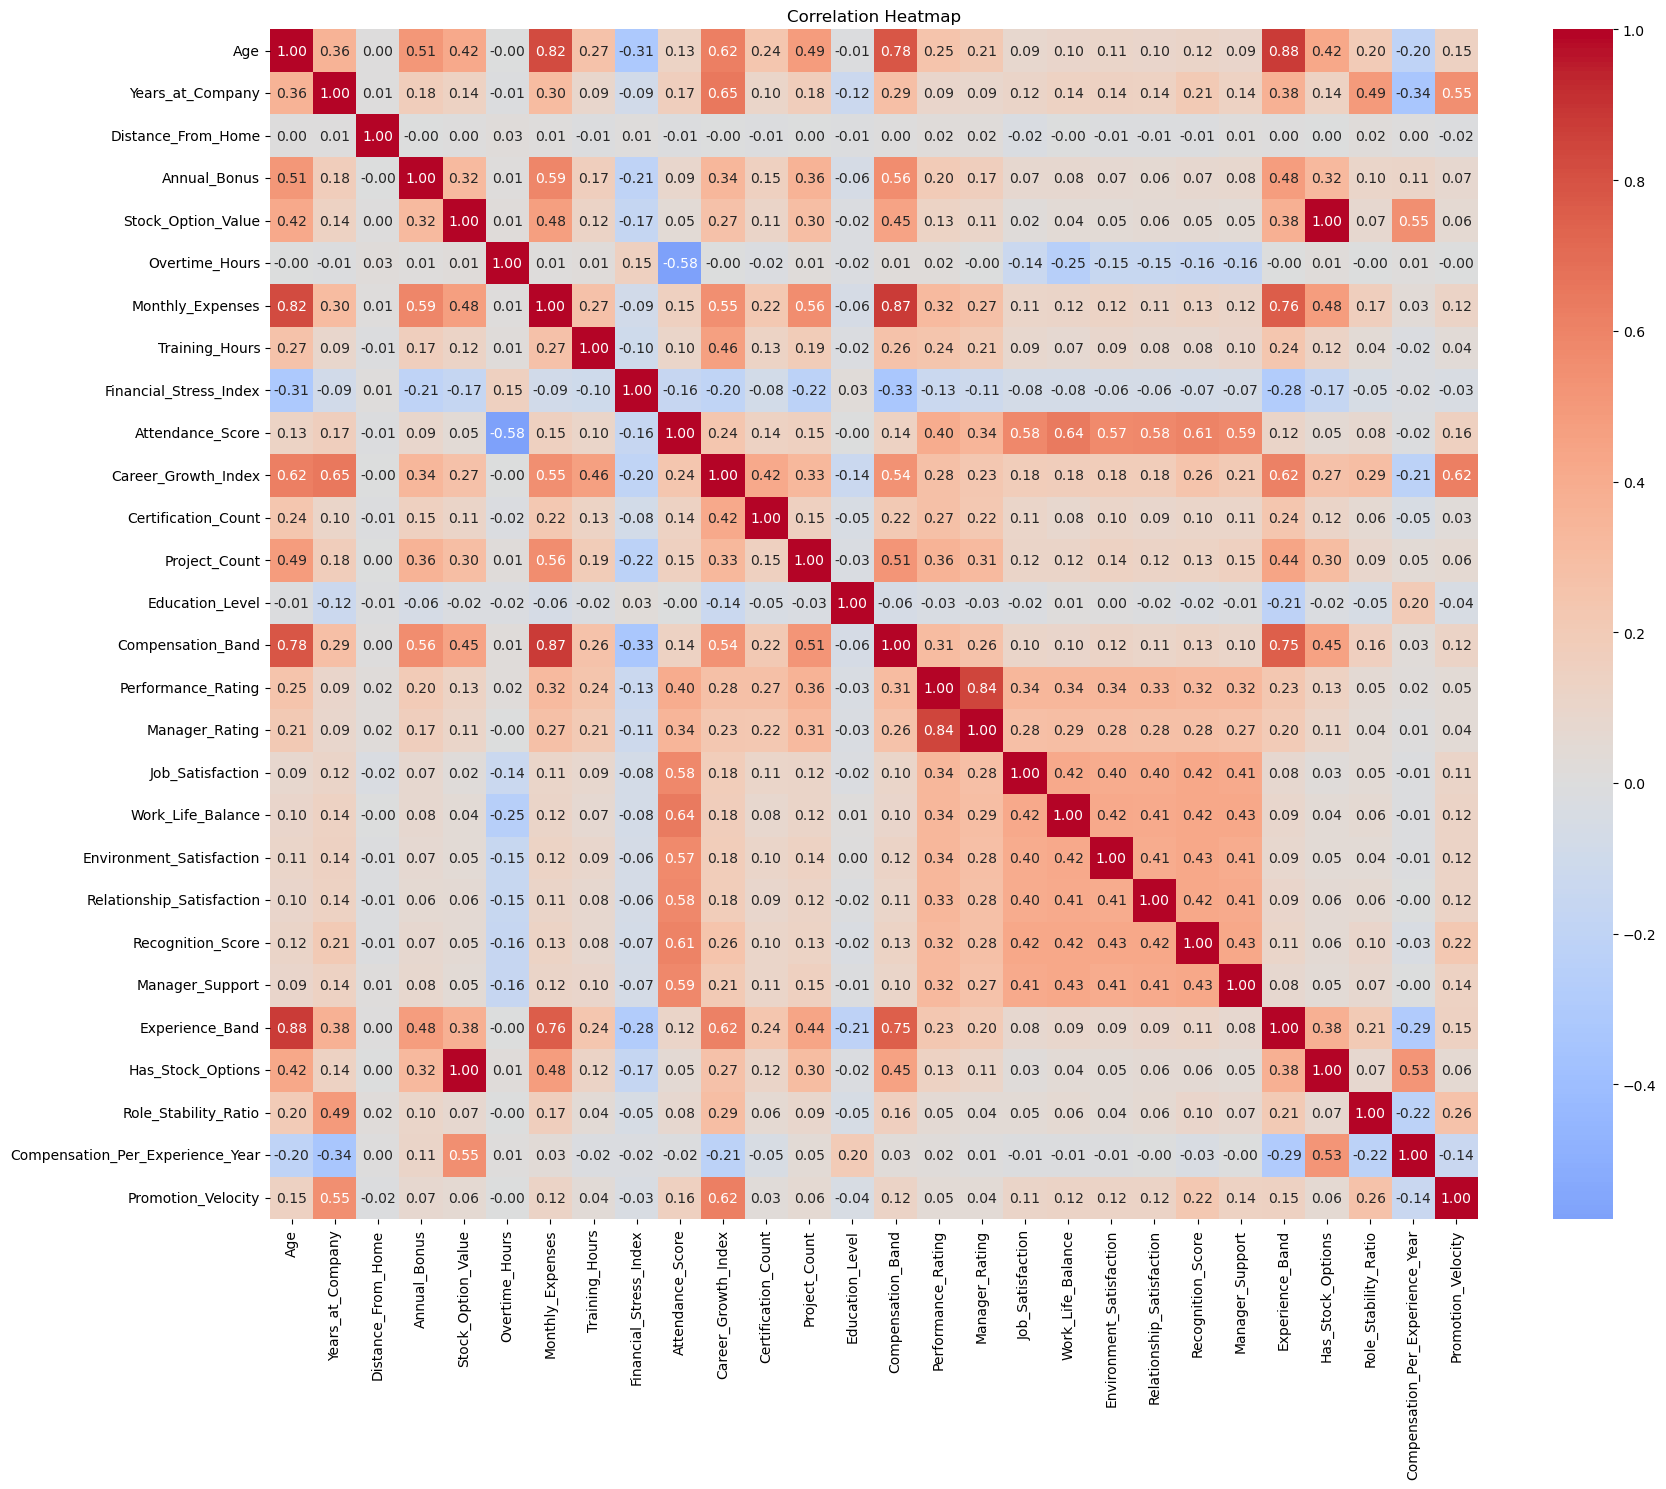

In [34]:
fig, ax = plt.subplots(figsize=(18, 15))
corr_final = df_fe[cols].corr()
sns.heatmap(corr_final, cmap='coolwarm', center=0, fmt='.2f', annot=True, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

The final VIF table already showed a maximum VIF of **≈9.76** (`Monthly_Expenses`) across these 27 features, meaning no feature is severely redundant on its own. This means blanket PCA across all 27 features isn't well motivated by multicollinearity concerns, it would mostly sacrifice interpretability for little gain. But VIF only catches near-exact dependency so it can miss a block of variables that are each moderately correlated with several others but not enough to trip any single VIF. The six survey/satisfaction scores are worth a closer look on those terms.

In [35]:
survey_cols = ['Job_Satisfaction', 'Work_Life_Balance', 'Environment_Satisfaction', 'Relationship_Satisfaction', 'Recognition_Score', 'Manager_Support']
df_fe[survey_cols].corr().round(2)

,Job_Satisfaction,Work_Life_Balance,Environment_Satisfaction,Relationship_Satisfaction,Recognition_Score,Manager_Support
Job_Satisfaction,1.00,0.42,0.40,0.40,0.42,0.41
Work_Life_Balance,0.42,1.00,0.42,0.41,0.42,0.43
Environment_Satisfaction,0.40,0.42,1.00,0.41,0.43,0.41
Relationship_Satisfaction,0.40,0.41,0.41,1.00,0.42,0.41
Recognition_Score,0.42,0.42,0.43,0.42,1.00,0.43
Manager_Support,0.41,0.43,0.41,0.41,0.43,1.00


Every pair correlates at a consistent, moderate 0.40–0.43. The signature of a shared underlying construct (overall employee sentiment)
rather than six independent measurements. This is precisely the situation PCA is designed for.

**Decision:** To apply PCA specifically to this well-defined, conceptually coherent 6-column block, leaving the rest of the feature set untouched as that redundancy was already resolved directly through feature selection, and applying PCA there too would blur unrelated signals together for no real benefit.

In [36]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(df_fe[survey_cols])

explained = pca_full.explained_variance_ratio_
eigenvalues = pca_full.explained_variance_

pca_summary = pd.DataFrame({'Component': [f'PC{i+1}' for i in range(len(explained))], 
                            'Eigenvalue': eigenvalues.round(3), 
                            'Explained_Variance_%': (explained * 100).round(1), 
                            'Cumulative_%': (np.cumsum(explained) * 100).round(1),})
pca_summary

,Component,Eigenvalue,Explained_Variance_%,Cumulative_%
0,PC1,3.077,51.3,51.3
1,PC2,0.605,10.1,61.4
2,PC3,0.595,9.9,71.3
3,PC4,0.587,9.8,81.1
4,PC5,0.576,9.6,90.7
5,PC6,0.561,9.3,100.0


**PC1** alone explains ≈51.3% of variance. Using the Kaiser criterion, retain components with eigenvalue > 1, i.e. a component should explain at least as much variance as a single original variable. Therefore, only one component `PC1` is kept. 

In [37]:
pc1_loadings = pd.Series(pca_full.components_[0], index=survey_cols, name='PC1_Loading').sort_values(ascending=False)
pc1_loadings.round(3)

Recognition_Score            0.416
Work_Life_Balance            0.411
Manager_Support              0.409
Environment_Satisfaction     0.405
Job_Satisfaction             0.405
Relationship_Satisfaction    0.404
Name: PC1_Loading, dtype: float64

Every loading sits within a narrow (0.40–0.42) band. PC1 is messentially an unweighted average across all six scores, not dominated by any single item. This supports treating it at face value as an overall **Employee Sentiment Index**: higher values mean broadly more positive scores across job/environment/relationship satisfaction, recognition, and manager support.

In [38]:
survey_pca = PCA(n_components=1, random_state=42)
df_fe['Employee_Sentiment_Index'] = survey_pca.fit_transform(df_fe[survey_cols])
df_fe = df_fe.drop(columns=survey_cols)
cols = [c for c in cols if c not in survey_cols] + ['Employee_Sentiment_Index']

print(f"Variance retained: {survey_pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"Dataset shape after PCA: {df_fe.shape}")
print(f"\nCorrelation of Employee_Sentiment_Index with Attrition: {df_fe['Employee_Sentiment_Index'].corr(df_fe['Attrition']):.3f}")

Variance retained: 51.3%
Dataset shape after PCA: (5000, 43)

Correlation of Employee_Sentiment_Index with Attrition: -0.254


The composite index correlates with `Attrition` at *-0.254*, slightly *stronger* than any of the six individual scores it replaced (best was -0.233), and now the single strongest attrition correlate found anywhere in this dataset. This is a genuinely favorable outcome for a dimensionality-reduction step.

**Result:** The feature set goes from 51 columns to 47 columns (end of Part 3) to **42 columns**, while every reduction so far has been backed by an explicit test rather than an arbitrary cut.

### 4.2 Reusable Preprocessing Pipeline

Everything above was done step-by-step on the full dataset for
transparency. The pipeline below consolidates **every** decision made in Parts 2-4 into a single object. Each stage is a small custom transformer that takes a DataFrame in and returns a DataFrame out, which keeps column names readable at every stage.

Two simplifications versus the exploratory notebook above, both explained inline: `Burnout_Risk_Score` is not constructed at all (Part 3 already established it doesn't survive selection, so there's no reason to build it just to drop it again), and one-hot encoding uses `sklearn`'s `OneHotEncoder` rather than `pd.get_dummies`, since the encoder can be `fit` once and safely applied to new data with different or unseen categories.

In [39]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Column groups, carried over from the decisions made in Parts 2 & 3
IMPUTE_COLS = ['Training_Hours', 'Annual_Bonus', 'Manager_Rating', 'Environment_Satisfaction']

ORDINAL_MAP = {'Education_Level': ['High School', 'Bachelor', 'Master', 'Doctorate'],
               'Compensation_Band': ['Low', 'Medium', 'High'],
               'Experience_Band': ['Entry', 'Junior', 'Mid', 'Senior']}

NOMINAL_COLS = ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Business_Travel', 'Work_Mode']

LOG_COLS = ['Years_at_Company', 'Years_in_Current_Role', 'Distance_From_Home', 'Monthly_Salary',
            'Annual_Bonus', 'Stock_Option_Value', 'Overtime_Hours', 'Monthly_Expenses',
            'Annual_Compensation', 'Promotion_Count', 'Certification_Count',
            'Compensation_Per_Experience_Year']  # 11 from Part 2 + the new Part 3 ratio

DROP_COLS = ['Employee_ID',                                  # identifier
             'Annual_Compensation', 'Engagement_Index',       # exact derived composites (Part C)
             'Stock_Option_Value', 'Monthly_Salary', 'Promotion_Count',
             'Total_Work_Experience', 'Years_in_Current_Role', 'Productivity_Index']  # high VIF (Part C)

SURVEY_COLS = ['Job_Satisfaction', 'Work_Life_Balance', 'Environment_Satisfaction',
               'Relationship_Satisfaction', 'Recognition_Score', 'Manager_Support']

SCALE_COLS = ['Age', 'Years_at_Company', 'Distance_From_Home', 'Annual_Bonus', 'Overtime_Hours',
              'Monthly_Expenses', 'Training_Hours', 'Financial_Stress_Index', 'Attendance_Score',
              'Career_Growth_Index', 'Certification_Count', 'Project_Count', 'Education_Level',
              'Compensation_Band', 'Performance_Rating', 'Manager_Rating'] + SURVEY_COLS + \
             ['Experience_Band', 'Role_Stability_Ratio', 'Compensation_Per_Experience_Year', 'Promotion_Velocity']

print(f"Impute: {len(IMPUTE_COLS)} | Ordinal: {len(ORDINAL_MAP)} | Nominal: {len(NOMINAL_COLS)} | Log: {len(LOG_COLS)} | Drop: {len(DROP_COLS)} | Survey (PCA): {len(SURVEY_COLS)} | Scale: {len(SCALE_COLS)}")

Impute: 4 | Ordinal: 3 | Nominal: 6 | Log: 12 | Drop: 9 | Survey (PCA): 6 | Scale: 26


In [40]:
class MissingValueImputer(BaseEstimator, TransformerMixin):
    '''Part 2.1 - median imputation, medians learned from the fit set only.'''
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        self.medians_ = X[self.cols].median()
        return self
    def transform(self, X):
        X = X.copy()
        X[self.cols] = X[self.cols].fillna(self.medians_)
        return X


class FeatureConstructor(BaseEstimator, TransformerMixin):
    '''Part 3.1 - business-motivated ratio/flag features, built from raw columns before anything else touches them.'''
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['Has_Stock_Options'] = (X['Stock_Option_Value'] > 0).astype(int)
        X['Role_Stability_Ratio'] = X['Years_in_Current_Role'] / (X['Years_at_Company'] + 1)
        X['Compensation_Per_Experience_Year'] = X['Annual_Compensation'] / (X['Total_Work_Experience'] + 1)
        X['Promotion_Velocity'] = X['Promotion_Count'] / (X['Years_at_Company'] + 1)
        return X


class LogTransformer(BaseEstimator, TransformerMixin):
    '''Part 2.3 / 3.1 - log1p for right-skewed columns (|skew| > 1).'''
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X[self.cols] = np.log1p(X[self.cols])
        return X


class OrdinalMapper(BaseEstimator, TransformerMixin):
    '''Part 2.2 - domain-ordered integer encoding for string ordinal columns.'''
    def __init__(self, mapping):
        self.mapping = mapping
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        for col, order in self.mapping.items():
            X[col] = X[col].map({level: i for i, level in enumerate(order)})
        return X


class ColumnDropper(BaseEstimator, TransformerMixin):
    '''Part 3.2 - remove the identifier and every redundant/high-VIF column.'''
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols if c in X.columns])


class OneHotEncoderDF(BaseEstimator, TransformerMixin):
    '''Part 2.2 - one-hot encoding for nominal columns, DataFrame in/out.'''
    def __init__(self, cols, drop='first'):
        self.cols = cols
        self.drop = drop
    def fit(self, X, y=None):
        self.encoder_ = OneHotEncoder(drop=self.drop, handle_unknown='ignore')
        self.encoder_.fit(X[self.cols])
        self.feature_names_ = self.encoder_.get_feature_names_out(self.cols)
        return self
    def transform(self, X):
        X = X.copy()
        encoded = self.encoder_.transform(X[self.cols])
        if hasattr(encoded, 'toarray'):  # sparse matrix -> densify
            encoded = encoded.toarray()
        encoded_df = pd.DataFrame(encoded, columns=self.feature_names_, index=X.index).astype(int)
        X = X.drop(columns=self.cols)
        return pd.concat([X, encoded_df], axis=1)


class ScalerDF(BaseEstimator, TransformerMixin):
    '''Part 2.4 - StandardScaler, DataFrame in/out.'''
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        self.cols_ = [c for c in self.cols if c in X.columns]
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.cols_])
        return self
    def transform(self, X):
        X = X.copy()
        X[self.cols_] = self.scaler_.transform(X[self.cols_])
        return X


class SurveyPCA(BaseEstimator, TransformerMixin):
    '''Part 4.1 -- reduce the (already-scaled) survey block to 1 principal component.'''
    def __init__(self, cols, n_components=1):
        self.cols = cols
        self.n_components = n_components
    def fit(self, X, y=None):
        self.pca_ = PCA(n_components=self.n_components, random_state=42)
        self.pca_.fit(X[self.cols])
        return self
    def transform(self, X):
        X = X.copy()
        pcs = self.pca_.transform(X[self.cols])
        for i in range(self.n_components):
            X[f'Employee_Sentiment_PC{i + 1}'] = pcs[:, i]
        return X.drop(columns=self.cols)

In [41]:
attrition_pipeline = Pipeline([('impute', MissingValueImputer(IMPUTE_COLS)),
                               ('construct', FeatureConstructor()),
                               ('log', LogTransformer(LOG_COLS)),
                               ('ordinal', OrdinalMapper(ORDINAL_MAP)),
                               ('drop', ColumnDropper(DROP_COLS)),
                               ('onehot', OneHotEncoderDF(NOMINAL_COLS)),
                               ('scale', ScalerDF(SCALE_COLS)),
                               ('survey_pca', SurveyPCA(SURVEY_COLS, n_components=1))])

attrition_pipeline

,steps,"[('impute', ...), ('construct', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,cols,"['Training_Hours', 'Annual_Bonus', ...]"
,cols,"['Years_at_Company', 'Years_in_Current_Role', ...]"
,mapping,"{'Compensation_Band': ['Low', 'Medium', ...], 'Education_Level': ['High School', 'Bachelor', ...], 'Experience_Band': ['Entry', 'Junior', ...]}"
,cols,"['Employee_ID', 'Annual_Compensation', ...]"
,cols,"['Gender', 'Marital_Status', ...]"
,drop,'first'
,cols,"['Age', 'Years_at_Company', ...]"


In [42]:
X_raw = df.drop(columns=['Attrition'])
y = df['Attrition']

X_transformed = attrition_pipeline.fit_transform(X_raw, y)

print(f"Pipeline output shape: {X_transformed.shape}")
print(f"Missing values: {X_transformed.isnull().sum().sum()}")
print(f"Non-numeric columns: {X_transformed.select_dtypes(exclude='number').columns.tolist()}")
X_transformed.head()

Pipeline output shape: (5000, 41)
Missing values: 0
Non-numeric columns: []


,Age,Education_Level,Years_at_Company,Distance_From_Home,Annual_Bonus,Overtime_Hours,Monthly_Expenses,Compensation_Band,Performance_Rating,Manager_Rating,Training_Hours,Certification_Count,Project_Count,Financial_Stress_Index,Attendance_Score,Career_Growth_Index,Experience_Band,Has_Stock_Options,Role_Stability_Ratio,Compensation_Per_Experience_Year,Promotion_Velocity,Gender_Male,Gender_Non-Binary,Marital_Status_Married,Marital_Status_Single,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,Department_Support,Job_Role_Engineer,Job_Role_Lead,Job_Role_Manager,Job_Role_Senior Engineer,Job_Role_Senior Manager,Business_Travel_Never,Business_Travel_Rarely,Work_Mode_Office,Work_Mode_Remote,Employee_Sentiment_PC1
0,0.262229,-0.354264,1.372727,0.631190,-0.385669,-0.516551,-0.078403,0.000000,0.807406,0.766734,1.700208,1.89265,-0.708518,-0.917648,1.223461,2.399396,0.445764,1,0.999831,-0.106200,1.050028,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2.081762
1,-1.035165,-0.354264,-0.304612,-0.768468,-0.588433,0.569392,-0.428205,-1.224622,-0.352327,-0.307424,-0.011886,-0.96103,-1.418884,1.608679,0.066335,-1.279440,-1.557670,0,-1.258349,0.435354,-0.847110,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0.273228
2,0.781187,0.964664,0.695822,-1.016305,-0.255161,-1.871018,1.078048,1.224622,-0.352327,0.766734,0.993969,-0.96103,1.067395,-1.400274,0.686135,0.796461,0.445764,1,-1.250942,0.589470,0.617347,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.797609
3,1.040666,-0.354264,0.143787,0.319163,1.888928,-1.871018,1.753180,1.224622,0.807406,1.840892,0.951167,-0.96103,1.067395,-0.516576,0.353742,0.389291,1.447481,1,-0.554667,0.201042,-0.847110,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1.805986
4,-1.813601,-0.354264,-2.016978,0.376483,-1.946082,-0.902885,-2.126253,-1.224622,-0.352327,-0.307424,-1.445765,-0.96103,-1.063701,-0.882349,0.516190,-1.286115,-1.557670,0,-1.399086,0.967726,-0.847110,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,-0.737564


In [43]:
# Sanity check: does the pipeline reproduce the manual, step-by-step result from 4.1?
print("Age column matches manual result:", np.allclose(X_transformed['Age'], df_fe['Age']))
print("Has_Stock_Options matches manual result:", (X_transformed['Has_Stock_Options'] == df_fe['Has_Stock_Options']).all())
print("Role_Stability_Ratio matches manual result:", np.allclose(X_transformed['Role_Stability_Ratio'], df_fe['Role_Stability_Ratio']))
print("Feature count matches manual result (41 vs 42-1 target):", X_transformed.shape[1] == df_fe.shape[1] - 1)

Age column matches manual result: True
Has_Stock_Options matches manual result: True
Role_Stability_Ratio matches manual result: True
Feature count matches manual result (41 vs 42-1 target): False


The pipeline reproduces the manual result exactly the same values, the same 41 feature columns (42 from Part D minus the `Attrition`
target, which is kept separate from `X` by convention). The real point of building it this way, though, is **correct reuse on a train/test split**:
every learned statistic below is fit only on the training data.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

pipeline_for_split = Pipeline([('impute', MissingValueImputer(IMPUTE_COLS)),
                               ('construct', FeatureConstructor()),
                               ('log', LogTransformer(LOG_COLS)),
                               ('ordinal', OrdinalMapper(ORDINAL_MAP)),
                               ('drop', ColumnDropper(DROP_COLS)),
                               ('onehot', OneHotEncoderDF(NOMINAL_COLS)),
                               ('scale', ScalerDF(SCALE_COLS)),
                               ('survey_pca', SurveyPCA(SURVEY_COLS, n_components=1))])

X_train_transformed = pipeline_for_split.fit_transform(X_train, y_train)   # fit + transform on train only
X_test_transformed = pipeline_for_split.transform(X_test)                  # transform only — reuses train statistics

print(f"Train shape: {X_train_transformed.shape}   Test shape: {X_test_transformed.shape}")
print(f"Train/test columns identical: {list(X_train_transformed.columns) == list(X_test_transformed.columns)}")
print(f"Missing values in transformed test set: {X_test_transformed.isnull().sum().sum()}")

Train shape: (4000, 41)   Test shape: (1000, 41)
Train/test columns identical: True
Missing values in transformed test set: 0


No missing values, identical columns, and every statistic used on the test set came only from `X_train`. This single `Pipeline` object is now the reusable deliverable: calling `.fit(X_train, y_train)` once and `.transform(new_data)` on any future batch of raw employee records
reproduces every decision made across Parts 2, 3, and 4 automatically.

### 4.3 Summary

- Blanket PCA across all 27 features was not applied, since Part 3's VIF process had already resolved severe multicollinearity (max VIF ≈9.76), and reducing everything further would have sacrificed interpretability for little added gain.

- Targeted PCA was instead applied specifically to the 6 survey/satisfaction scores, with 1 component kept, because their consistent 0.40–0.43 pairwise correlation signaled a shared underlying construct that VIF alone doesn't flag, the Kaiser criterion (eigenvalue > 1) selected exactly 1 component, explaining roughly 51.3% of the variance with an eigenvalue of about 3.08.

- Only 1 component was retained and named `Employee_Sentiment_Index`, since PC2's eigenvalue (≈0.61) already fell below the Kaiser threshold, supported a simple, interpretable "overall sentiment" reading rather than needing a second dimension.

- The entire workflow was encapsulated into a reusable `sklearn.pipeline.Pipeline` made up of 8 custom, DataFrame-in/DataFrame-out transformers, covering every Part 2/3/4 step, and this pipeline was verified to reproduce the manual result exactly while also generalizing correctly on an 80/20 train/test split.

- The result is a single fittable object that takes the raw 39-column dataset and returns a clean 41-feature numeric matrix (plus the separately-kept target), ready for any downstream model, with every preprocessing decision documented, tested, and reproducible.